# **Principal Component Analysis**

Principal component analysis, or PCA, is a dimensionality reduction method that is often used to reduce the dimensionality of large data sets, by transforming a large set of variables into a smaller one that still contains most of the information in the large set.

## Importing Libraries

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np


## Importing a Dataset

In [25]:
df = pd.read_csv("../Datasets/Iris.csv")

In [26]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [27]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000    

## Defining Target and Independent Variables

In [28]:
X = df.select_dtypes(include=['float64', 'int64'])
X = X.drop(columns=['Id'])

In [29]:
Y = df.select_dtypes(include=['object'])
Y

/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_40061/1875132828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Y = df.select_dtypes(include=['object'])


,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


## Applying Standard Scaler and Finding Covariance Matrix 

In [30]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [31]:
cov_mat = np.cov(X_scaled.T)
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)
print("Eigenvalues:\n {} \n".format(eigen_values))
print("Eigenvectors:\n {} \n".format(eigen_vectors))
print("Covariance Matrix:\n {} \n".format(cov_mat))

Eigenvalues:
 [2.93035378 0.92740362 0.14834223 0.02074601] 

Eigenvectors:
 [[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]] 

Covariance Matrix:
 [[ 1.00671141 -0.11010327  0.87760486  0.82344326]
 [-0.11010327  1.00671141 -0.42333835 -0.358937  ]
 [ 0.87760486 -0.42333835  1.00671141  0.96921855]
 [ 0.82344326 -0.358937    0.96921855  1.00671141]] 



## Getting Eigen Values in Descending Order

In [32]:
eigen_pairs = [(np.abs(eigen_values[i]), eigen_vectors[:,i]) for i in range(len(eigen_values))]
print("Eigen Values in descending order:")
eigen_pairs.sort(key=lambda x: x[0], reverse=True)
for eigen_value, eigen_vector in eigen_pairs:
    print(eigen_value)

Eigen Values in descending order:
2.930353775589317
0.9274036215173418
0.14834222648163986
0.020746013995595867


## Performing PCA

In [33]:
pca = PCA()
pca = pca.fit(X_scaled)

In [34]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.72770452, 0.23030523, 0.03683832, 0.00515193])

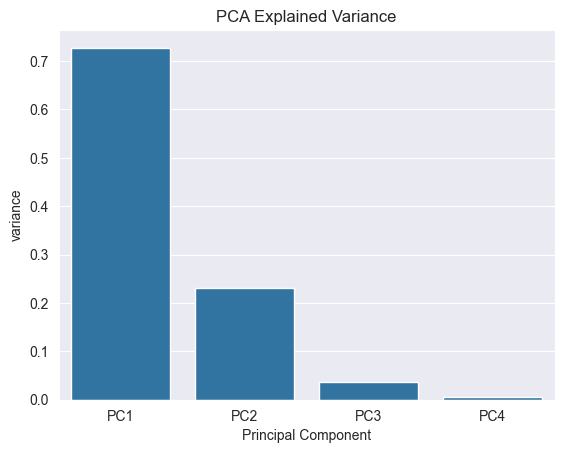

In [35]:
dataframe = pd.DataFrame({'variance': explained_variance,
                          'Principal Component': ['PC1', 'PC2', 'PC3', 'PC4']})
sns.barplot(x='Principal Component', y='variance', data=dataframe)
plt.title('PCA Explained Variance')
plt.show()

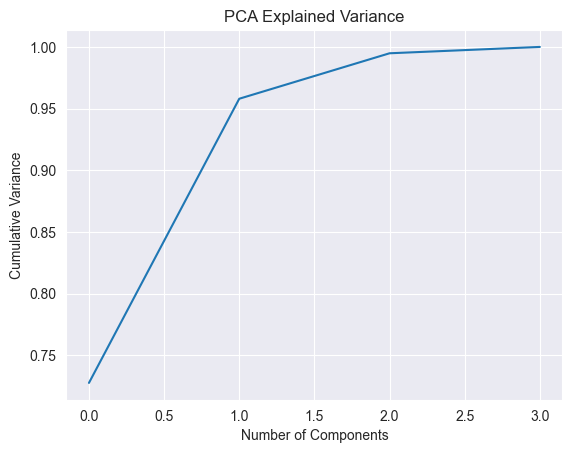

In [36]:
plt.plot(np.cumsum(explained_variance))
plt.title('PCA Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.show()

In [37]:
pca_2 = PCA(n_components=2)
pca_2 = pca_2.fit(X_scaled)
pca_2d = pca_2.transform(X)

/Users/anshumaansoni/PycharmProjects/Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


In [38]:
df['Species'] = df['Species'].replace({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

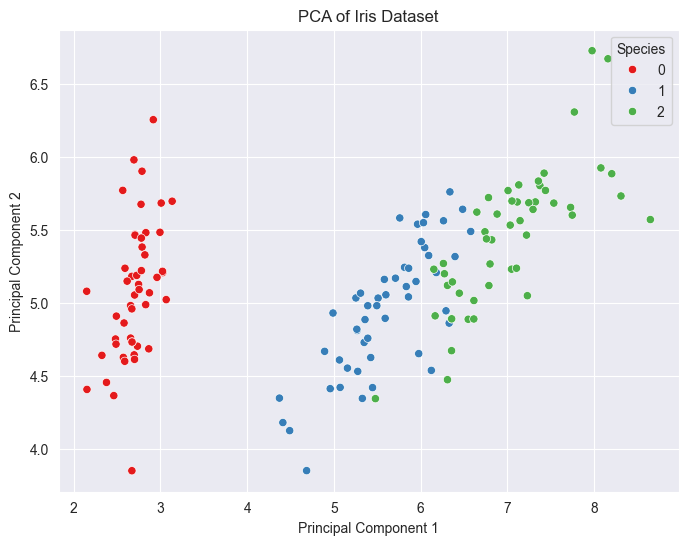

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=df['Species'], palette='Set1')
plt.title('PCA of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Species', loc='best')
plt.show()

In [40]:
pca_4 = PCA(n_components=4)
pca_4 = pca_4.fit(X_scaled)
pca_4d = pca_4.transform(X)

/Users/anshumaansoni/PycharmProjects/Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


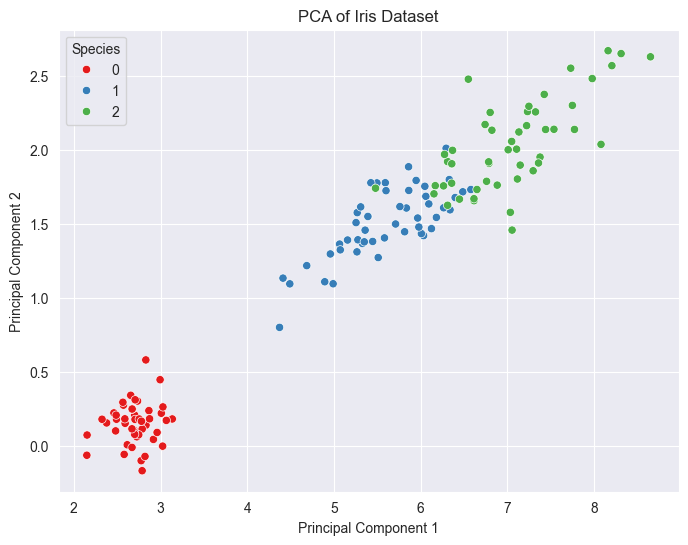

In [41]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_4d[:,0], y=pca_4d[:,3], hue=df['Species'], palette='Set1')
plt.title('PCA of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Species', loc='best')
plt.show()

## Supervised Learning Model
### 1. Training before applying PCA

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Using the scaled features X_scaled and target df['Species']
y = df['Species'].astype('int')

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy before PCA:", accuracy_score(y_test, y_pred))

Accuracy before PCA: 1.0


### 2. Training after applying PCA

In [43]:
# Using PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model_pca = LogisticRegression()
model_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = model_pca.predict(X_test_pca)

print("Accuracy after PCA:", accuracy_score(y_test_pca, y_pred_pca))

Accuracy after PCA: 0.9


## Inference
The accuracy of the model before applying PCA is 1.0, which indicates that the model is able to perfectly classify the Iris dataset using all the features.
After applying PCA and reducing the dimensions to 2 principal components, the accuracy drops slightly to 0.9. This is expected as we are losing some information by reducing the dimensions. However, the drop in accuracy is minimal, and the model still performs very well with just 2 components, which simplifies the model and makes it easier to visualize.
This demonstrates the power of PCA in reducing dimensionality while retaining most of the important information for classification tasks.